In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\user\Desktop\NTI\Telecom_Normal_traffiv.csv")
df.head()

,SINR,RSRP,RSRQ,RSSI,DL,UL,RSSI_RSRP_ratio,delta_SINR,rolling_sinr_5,Normal_traffic
0,23.937290,-72.303092,-10.446337,-58.856048,20.770725,8.372476,-0.814018,0.000000,23.937290,1
1,10.304483,-89.828913,-4.656395,-81.035061,28.596963,10.349123,-0.902104,-13.632807,17.120886,1
2,16.901540,-85.945951,-12.066784,-72.993062,28.199100,7.753250,-0.849290,6.597057,17.047771,1
3,20.113274,-86.098347,-8.937873,-79.765436,12.364144,7.258741,-0.926446,3.211733,17.814146,1
4,16.659428,-87.306335,-9.386310,-76.584593,27.442078,12.989094,-0.877194,-3.453845,17.583203,1


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5140 entries, 0 to 5139
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SINR             5140 non-null   float64
 1   RSRP             5140 non-null   float64
 2   RSRQ             5140 non-null   float64
 3   RSSI             5140 non-null   float64
 4   DL               5140 non-null   float64
 5   UL               5140 non-null   float64
 6   RSSI_RSRP_ratio  5140 non-null   float64
 7   delta_SINR       5140 non-null   float64
 8   rolling_sinr_5   5140 non-null   float64
 9   Normal_traffic   5140 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 401.7 KB


In [184]:
df.describe()

,SINR,RSRP,RSRQ,RSSI,DL,UL,RSSI_RSRP_ratio,delta_SINR,rolling_sinr_5,Normal_traffic
count,5140.000000,5140.000000,5140.000000,5140.000000,5140.000000,5140.000000,5140.000000,5140.000000,5140.000000,5140.000000
mean,17.030174,-85.058461,-9.840255,-73.207160,26.124013,7.249992,-0.860198,-0.000608,17.030309,0.862646
std,8.530965,5.057866,3.328002,7.596524,12.253611,3.580459,0.067769,12.055637,3.871694,0.344254
min,-13.860393,-104.183278,-27.477264,-95.030410,0.000000,0.000000,-1.011384,-37.969665,-1.178851,0.000000
25%,15.584128,-88.431720,-10.845043,-78.291075,20.926845,5.143434,-0.902372,-5.262286,14.632266,1.000000
50%,19.254565,-85.084041,-9.257034,-73.925717,28.294391,7.597850,-0.874382,-0.082941,17.599516,1.000000
75%,22.212269,-81.567964,-7.858652,-69.043659,34.454981,9.706941,-0.841823,5.296814,20.034478,1.000000
max,35.704951,-67.354724,-2.244464,-42.056132,61.538648,18.834050,-0.530251,35.650216,26.750315,1.000000


In [ ]:
x = df.drop(['Normal_traffic','rolling_sinr_5','delta_SINR', 'SINR',"DL"], axis=1)
y = df['Normal_traffic']

In [186]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



In [187]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=6)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Model accuracy score with 200 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))


Model accuracy score with 200 decision-trees : 0.9737


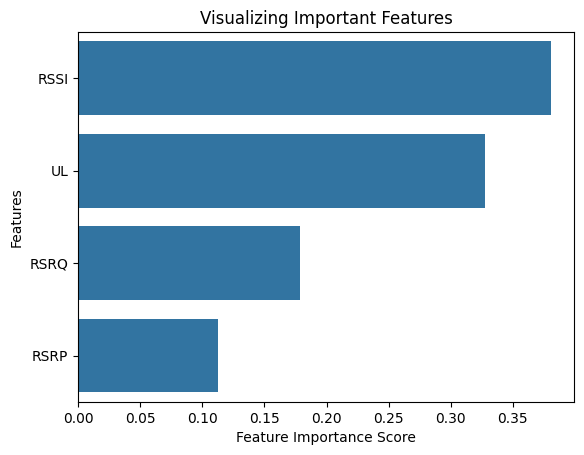

In [188]:
# view the feature scores

feature_scores = pd.Series(model.feature_importances_, index=x_train.columns).sort_values(ascending=False)

feature_scores

# Creating a seaborn bar plot

sns.barplot(x=feature_scores, y=feature_scores.index)



# Add labels to the graph

plt.xlabel('Feature Importance Score')

plt.ylabel('Features')



# Add title to the graph

plt.title("Visualizing Important Features")



# Visualize the graph

plt.show()

              precision    recall  f1-score   support

           0       0.92      0.87      0.90       133
           1       0.98      0.99      0.98       895

    accuracy                           0.97      1028
   macro avg       0.95      0.93      0.94      1028
weighted avg       0.97      0.97      0.97      1028



<Axes: >

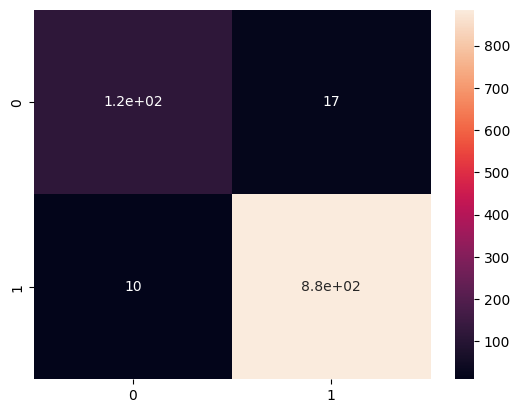

In [189]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)

ROC-AUC Score: 0.9645


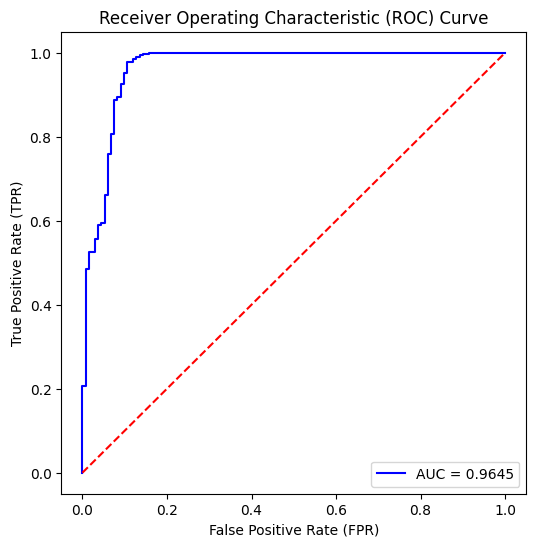

In [190]:
# --- ROC-AUC Evaluation ---

from sklearn.metrics import roc_auc_score, roc_curve

# Get predicted probabilities for the positive class (class = 1)
# [:,1] takes the probability of being in class 1
y_proba = model.predict_proba(x_test)[:, 1]

# Compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], color="red", linestyle="--")  # diagonal line (random classifier)

# Labels
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()


Permutation Importances (mean drop in ROC-AUC when shuffled):
RSSI    0.150713
RSRP    0.034998
UL      0.012143
RSRQ    0.010092
dtype: float64


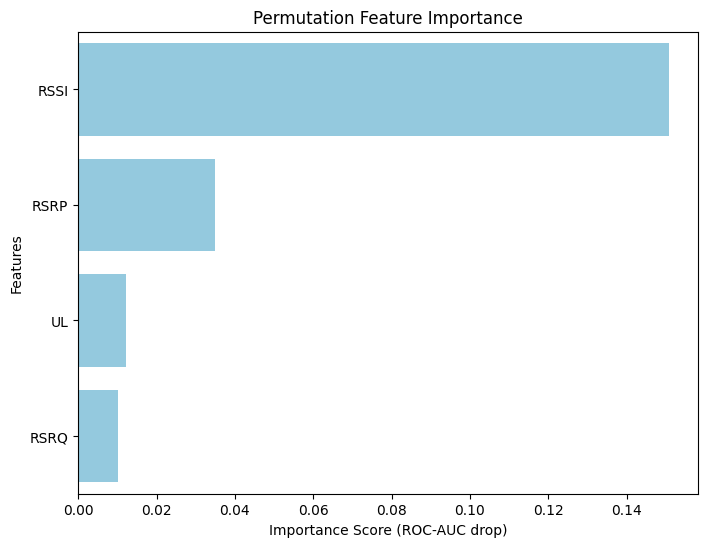

In [191]:
# --- Permutation Importance ---

# Import the tool
from sklearn.inspection import permutation_importance

# Compute permutation importance
# n_repeats=10 means we shuffle each feature 10 times to get a stable estimate
# scoring='roc_auc' ensures importance is measured in terms of ROC-AUC drop
result = permutation_importance(
    model, x_test, y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='roc_auc'
)

# Convert to pandas Series for easy handling
perm_importances = pd.Series(result.importances_mean, index=x_test.columns).sort_values(ascending=False)

# Print values
print("Permutation Importances (mean drop in ROC-AUC when shuffled):")
print(perm_importances)

# --- Visualization ---
plt.figure(figsize=(8,6))
sns.barplot(x=perm_importances, y=perm_importances.index, color="skyblue")

# Add labels and title
plt.xlabel("Importance Score (ROC-AUC drop)")
plt.ylabel("Features")
plt.title("Permutation Feature Importance")

# Show the plot
plt.show()


In [192]:
# shapes and columns
print("df.shape:", df.shape)
print("x.shape:", x.shape)
print("y.shape:", y.shape)
print("x.columns:", list(x.columns))
print("y.unique():", np.unique(y), "value counts:\n", y.value_counts())


df.shape: (5140, 10)
x.shape: (5140, 4)
y.shape: (5140,)
x.columns: ['RSRP', 'RSRQ', 'RSSI', 'UL']
y.unique(): [0 1] value counts:
 Normal_traffic
1    4434
0     706
Name: count, dtype: int64


In [193]:
# after train_test_split
print("x_train.shape, x_test.shape:", x_train.shape, x_test.shape)
# Confirm you used these exactly:
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)   # <-- must be x_test, not x or x_train


x_train.shape, x_test.shape: (4112, 4) (1028, 4)


In [194]:
for col in x.columns:
    if (df[col].equals(df['Normal_traffic'])):
        print("COLUMN EQUAL TO LABEL:", col)
    # also check after converting to int (sometimes label encoded as 0/1 floats)
    if (df[col].astype(float) == df['Normal_traffic'].astype(float)).all():
        print("COLUMN EQUAL TO LABEL (after astype):", col)


In [195]:
def is_perfectly_threshold_separable(z, y):
    if (y==0).sum()==0 or (y==1).sum()==0:
        return False, None, None
    z0 = z[y==0].max()
    z1 = z[y==1].min()
    return z0 < z1, z0, z1

for col in x.columns:
    separable, z0, z1 = is_perfectly_threshold_separable(df[col], df['Normal_traffic'])
    if separable:
        print(f"{col} is perfectly separable by threshold: max_neg={z0}, min_pos={z1}")


In [196]:
# duplicates in full dataset
print("Total duplicate rows in df:", df.duplicated().sum())

# overlap between train and test (exact match on all columns)
merged = pd.merge(x_train.reset_index(), x_test.reset_index(), how='inner', on=list(x.columns))
print("Exact row overlap between train and test:", merged.shape[0])


Total duplicate rows in df: 0
Exact row overlap between train and test: 0


In [197]:
# show a few suspicious rows from test set with all columns
display(pd.concat([x_test.reset_index(drop=True).head(10), y_test.reset_index(drop=True).head(10)], axis=1))


,RSRP,RSRQ,RSSI,UL,Normal_traffic
0,-87.663627,-10.964039,-73.695774,4.846605,1
1,-84.227532,-12.272806,-74.799107,11.052265,1
2,-94.683764,-8.707049,-85.410628,11.070300,1
3,-83.883646,-6.713277,-72.824528,5.952594,1
4,-88.156997,-18.865042,-60.232799,0.155726,0
5,-87.144240,-5.669715,-77.555875,8.154176,1
6,-84.430147,-8.561592,-73.674538,13.074951,1
7,-76.803717,-8.810637,-68.395458,9.606913,1
8,-84.995831,-8.672189,-64.384853,7.678919,0
9,-80.507441,-8.274914,-69.108074,8.286381,1


In [198]:
for col in x.columns:
    if x[col].nunique() <= 1:
        print("Constant column:", col)


In [199]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=1, random_state=42)  # stump
dt.fit(x_train, y_train)
print(classification_report(y_test, dt.predict(x_test)))


              precision    recall  f1-score   support

           0       0.98      0.68      0.80       133
           1       0.95      1.00      0.98       895

    accuracy                           0.96      1028
   macro avg       0.97      0.84      0.89      1028
weighted avg       0.96      0.96      0.95      1028



In [200]:
imp = pd.Series(model.feature_importances_, index=x_train.columns).sort_values(ascending=False)
print("Top features:\n", imp.head(10))

# show min/max per class for top 5 features
top5 = list(imp.head(5).index)
for col in top5:
    print(col, "neg max:", df.loc[df['Normal_traffic']==0, col].max(),
                 "pos min:", df.loc[df['Normal_traffic']==1, col].min())


Top features:
 RSSI    0.375345
UL      0.293942
RSRQ    0.180645
RSRP    0.150068
dtype: float64
RSSI neg max: -42.05613204148354 pos min: -95.03040979246816
UL neg max: 17.52509159103289 pos min: 0.0
RSRQ neg max: -4.062096284298936 pos min: -16.844800503236684
RSRP neg max: -70.96174608360559 pos min: -104.18327774229684


In [201]:
print("Feature used for split:", x_train.columns[dt.tree_.feature[0]])
print("Threshold used:", dt.tree_.threshold[0])

Feature used for split: UL
Threshold used: 0.7023479342460632
